# Logistic Regression Model Training, Evaluation & XAI

 mariamzakary


---
## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
!pip install lime
import lime
import lime.lime_tabular

print('All imports OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=faa4bf1569ee1b4b5ed4ea65fa98bb50fb7f15cb8a4ecd9fffbec70897a382a1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
All imports OK


---
## 1. Data Loading, Preprocessing & Feature Engineering

In [2]:
df = pd.read_csv('cardiovascular_diseases_processed.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1


In [3]:
# Outlier capping
df_clean = df.drop(columns=['AGE_GROUP'], errors='ignore').copy()
for col in ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']:
    lo, hi = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lo, hi)

# Feature engineering
df_clean['BMI']            = df_clean['WEIGHT'] / (df_clean['HEIGHT'] / 100) ** 2
df_clean['PULSE_PRESSURE'] = df_clean['AP_HIGH'] - df_clean['AP_LOW']
df_clean['MAP']            = (df_clean['AP_HIGH'] + 2 * df_clean['AP_LOW']) / 3
df_clean['HYPERTENSION']   = ((df_clean['AP_HIGH'] >= 140) | (df_clean['AP_LOW'] >= 90)).astype(int)
df_clean['OBESE']          = (df_clean['BMI'] >= 30).astype(int)

X = df_clean.drop(columns=['CARDIO_DISEASE'])
y = df_clean['CARDIO_DISEASE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (55026, 16) | Test: (13757, 16)


---
# MODEL 2 — Logistic Regression
---

## 2.1 Train & Evaluate

In [4]:
lr = LogisticRegression(penalty='l2', C=0.5, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, lr_prob):.4f}')
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

Accuracy: 0.7203
ROC-AUC:  0.7886
              precision    recall  f1-score   support

  No Disease       0.70      0.79      0.74      6949
     Disease       0.75      0.65      0.70      6808

    accuracy                           0.72     13757
   macro avg       0.72      0.72      0.72     13757
weighted avg       0.72      0.72      0.72     13757



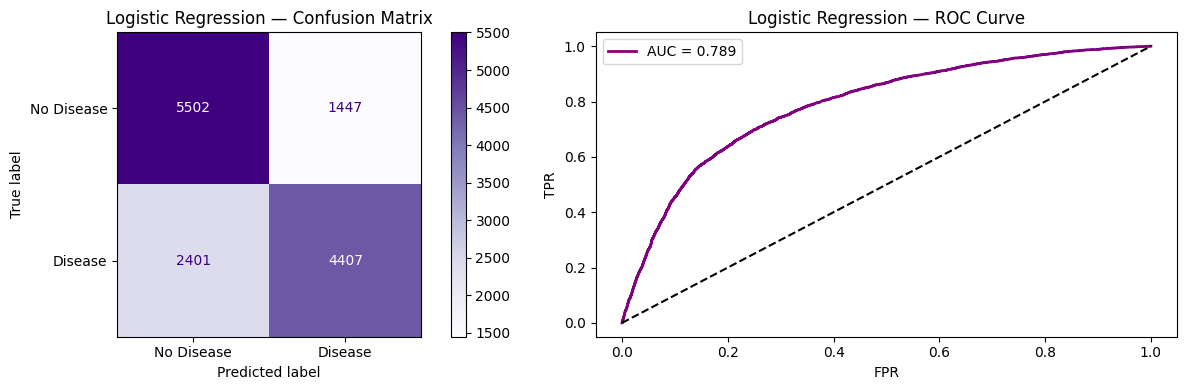

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=['No Disease', 'Disease'], cmap='Purples', ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, lr_prob)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc_score(y_test, lr_prob):.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Logistic Regression — ROC Curve'); axes[1].legend()

plt.tight_layout(); plt.show()

## 2.2 XAI — SHAP

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

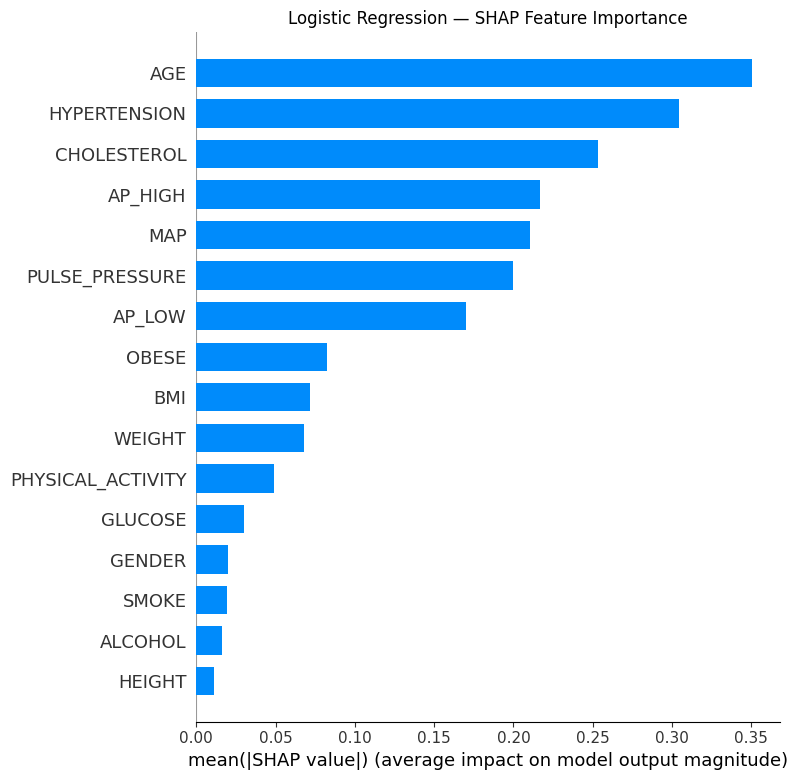

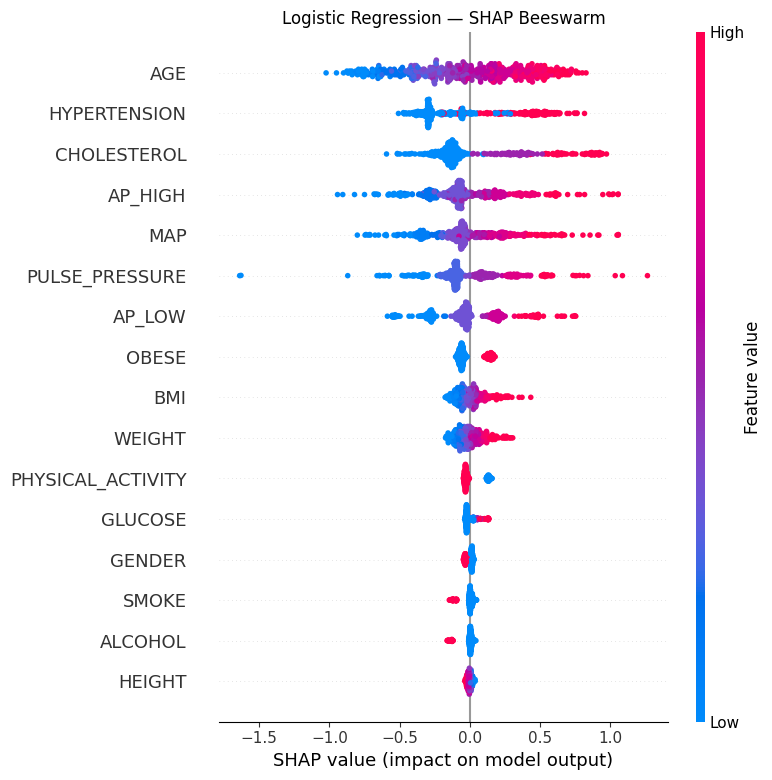

In [6]:
bg = shap.sample(X_train_scaled, 200, random_state=42)
explainer_lr = shap.LinearExplainer(lr, bg, feature_perturbation='correlation_dependent')
shap_lr_sample = X_test_scaled.sample(500, random_state=42)
shap_lr = explainer_lr.shap_values(shap_lr_sample)

# Global bar
shap.summary_plot(shap_lr, shap_lr_sample, plot_type='bar', show=False)
plt.title('Logistic Regression — SHAP Feature Importance')
plt.tight_layout(); plt.show()

# Beeswarm
shap.summary_plot(shap_lr, shap_lr_sample, show=False)
plt.title('Logistic Regression — SHAP Beeswarm')
plt.tight_layout(); plt.show()

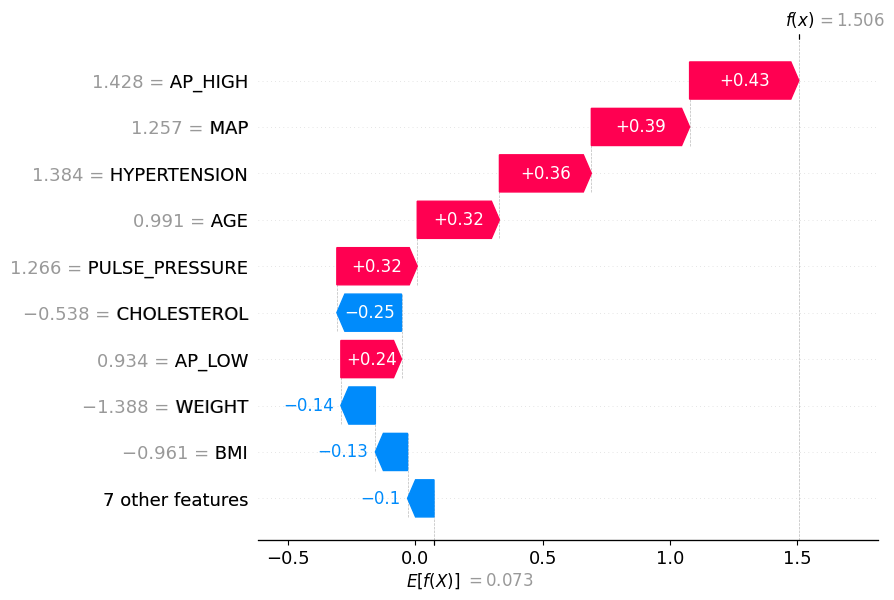

In [7]:
# Waterfall — single patient
shap.plots.waterfall(shap.Explanation(
    values        = shap_lr[0],
    base_values   = explainer_lr.expected_value,
    data          = shap_lr_sample.iloc[0],
    feature_names = shap_lr_sample.columns.tolist()
))

## 2.3 XAI — LIME

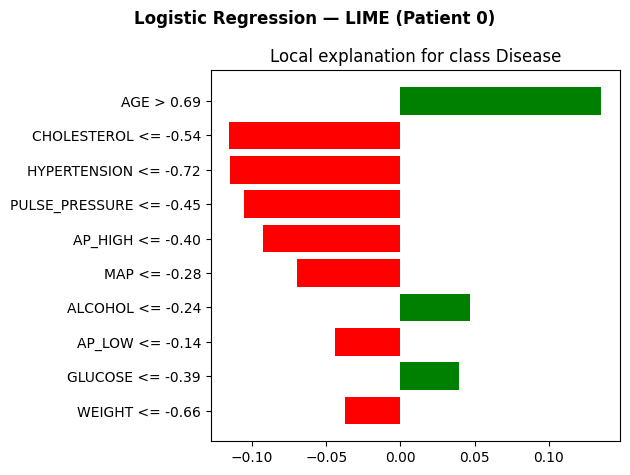

In [8]:
lime_exp_lr = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled.values,
    feature_names = X_train_scaled.columns.tolist(),
    class_names   = ['No Disease', 'Disease'],
    mode          = 'classification',
    random_state  = 42
)

exp_lr = lime_exp_lr.explain_instance(
    X_test_scaled.iloc[0].values,
    lr.predict_proba,
    num_features=10, num_samples=3000
)

fig = exp_lr.as_pyplot_figure()
fig.suptitle('Logistic Regression — LIME (Patient 0)', fontweight='bold')
plt.tight_layout(); plt.show()

## 2.4 XAI — PDP

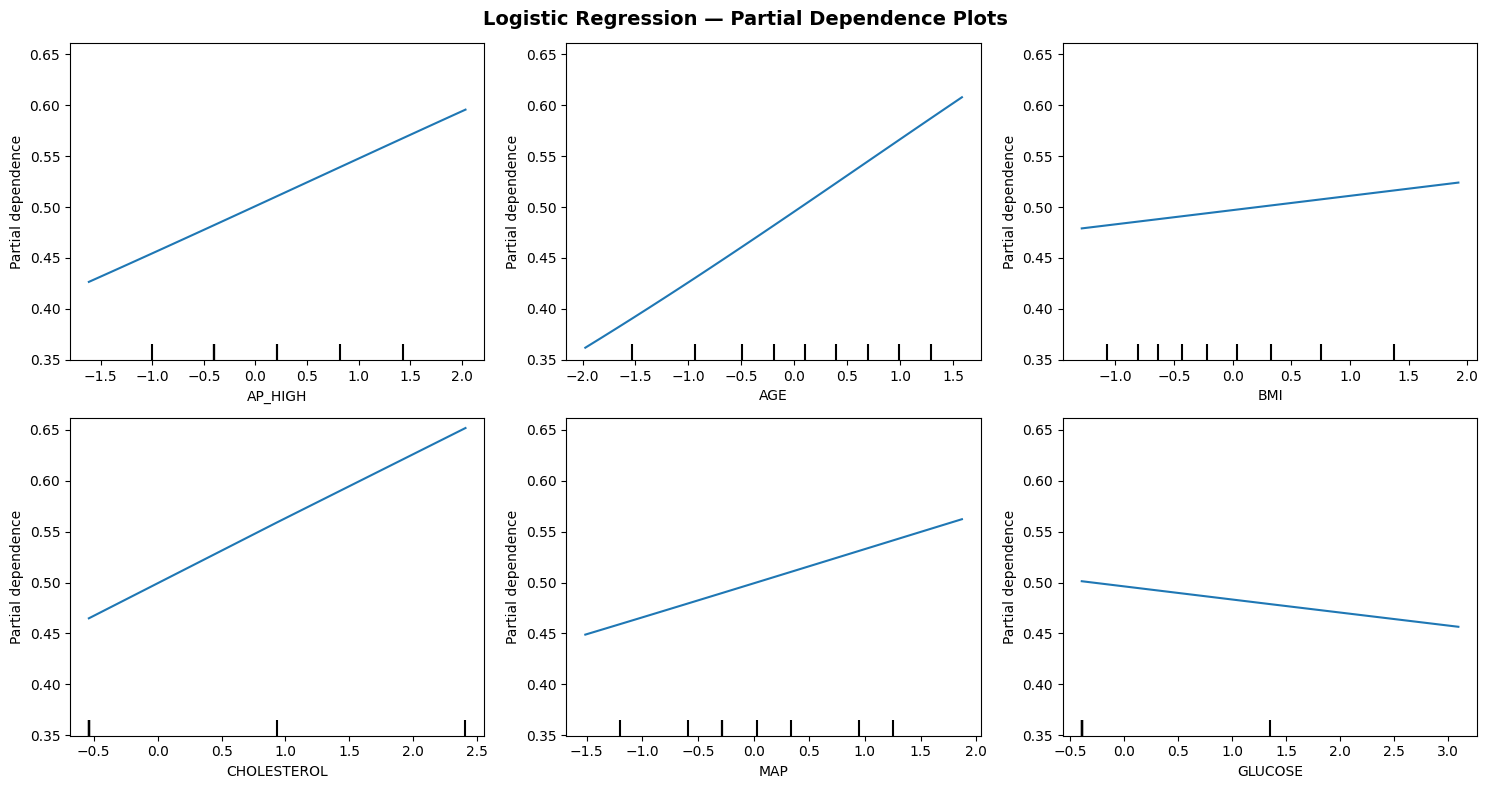

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    lr, X_test_scaled,
    features        = ['AP_HIGH', 'AGE', 'BMI', 'CHOLESTEROL', 'MAP', 'GLUCOSE'],
    kind            = 'average',
    grid_resolution = 50,
    ax              = axes.ravel(),
    n_jobs          = -1
)
fig.suptitle('Logistic Regression — Partial Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 2.5 XAI — Permutation Importance

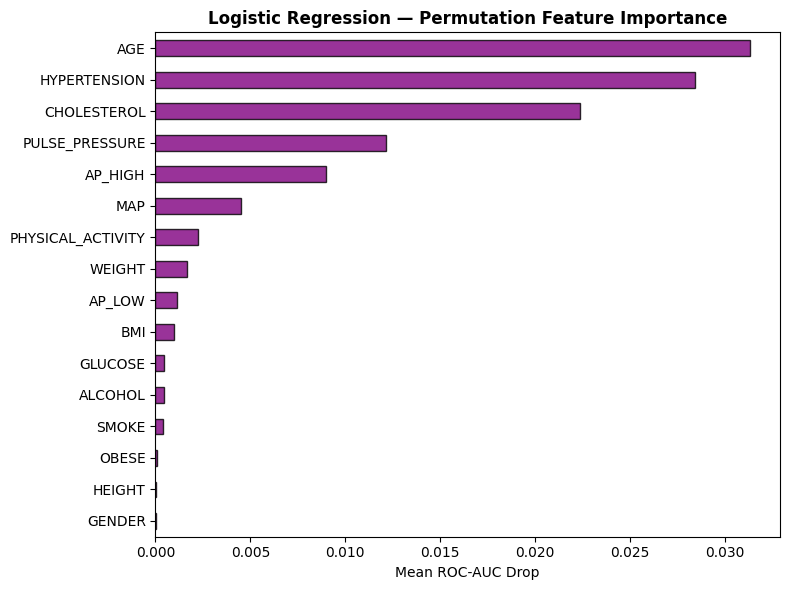

In [10]:
perm_lr = permutation_importance(
    lr, X_test_scaled, y_test,
    scoring='roc_auc', n_repeats=15, random_state=42, n_jobs=-1
)

perm_lr_df = pd.Series(
    perm_lr.importances_mean, index=X_test_scaled.columns
).sort_values(ascending=True)

perm_lr_df.plot(kind='barh', figsize=(8, 6), color='purple', edgecolor='black', alpha=0.8)
plt.xlabel('Mean ROC-AUC Drop')
plt.title('Logistic Regression — Permutation Feature Importance', fontweight='bold')
plt.tight_layout(); plt.show()